# Demo 1: Binary Classification with Simpsons Characters

This demo introduces binary classification using the Simpsons-MNIST dataset. The goal is to predict whether a 28x28 RGB image shows **Homer Simpson** or **Bart Simpson** based on pixel values.

## Learning Objectives

By the end of this demo, you will be able to:

1. Load and explore an image classification dataset
2. Visualize sample images from different classes
3. Split data into train/validation/test sets properly
4. Use cross-validation to evaluate model performance
5. Train a final model and evaluate on held-out test data

## 0. Setup

In [21]:
%pip install -r requirements.txt --quiet

Note: you may need to restart the kernel to use updated packages.


In [22]:
from pathlib import Path

# Clone Simpsons-MNIST dataset if not already present
DATA_DIR = Path('simpsons_data/dataset')
if not DATA_DIR.exists():
    !git clone --depth 1 --filter=blob:none --sparse https://github.com/alvarobartt/simpsons-mnist.git simpsons_data
    !cd simpsons_data && git sparse-checkout set dataset/rgb
    print("Done!")
else:
    print(f"Dataset already exists at {DATA_DIR}")

Dataset already exists at simpsons_data/dataset


## 1. Load the Simpsons-MNIST Dataset

The Simpsons-MNIST dataset contains 10,000 images (8,000 train + 2,000 test) of 10 Simpsons characters, each as a 28x28 RGB image. We'll load the RGB version to preserve color information (Marge's blue hair, Homer's skin tone, etc.) and focus on two characters for binary classification.

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image

# Character label mapping
CHARACTERS = {
    0: 'Bart Simpson',
    1: 'Mr. Burns',
    2: 'Homer Simpson',
    3: 'Krusty',
    4: 'Lisa Simpson',
    5: 'Marge Simpson',
    6: 'Milhouse',
    7: 'Moe',
    8: 'Ned Flanders',
    9: 'Principal Skinner'
}

# Folder names in dataset
FOLDER_NAMES = [
    'bart_simpson', 'charles_montgomery_burns', 'homer_simpson',
    'krusty_the_clown', 'lisa_simpson', 'marge_simpson',
    'milhouse_van_houten', 'moe_szyslak', 'ned_flanders', 'principal_skinner'
]

def load_simpsons_mnist(data_dir, split='train'):
    """Load Simpsons-MNIST images from directory structure."""
    images, labels = [], []
    base_path = Path(data_dir) / 'rgb' / split

    for label, folder in enumerate(FOLDER_NAMES):
        folder_path = base_path / folder
        if not folder_path.exists():
            continue
        for img_path in sorted(folder_path.glob('*.jpg')):
            img = Image.open(img_path).convert('RGB')  # RGB (3 channels)
            img_array = np.array(img).flatten()  # Flatten to 2352 pixels (28x28x3)
            images.append(img_array)
            labels.append(label)

    return np.array(images), np.array(labels)

# Load both train and test sets (DATA_DIR defined in setup cell)
X_train_full, y_train_full = load_simpsons_mnist(DATA_DIR, 'train')
X_test_full, y_test_full = load_simpsons_mnist(DATA_DIR, 'test')

f"Train: {X_train_full.shape}, Test: {X_test_full.shape}"

'Train: (8000, 2352), Test: (2000, 2352)'

In [24]:
# Class distribution
pd.Series(y_train_full).map(CHARACTERS).value_counts()

Bart Simpson         800
Mr. Burns            800
Homer Simpson        800
Krusty               800
Lisa Simpson         800
Marge Simpson        800
Milhouse             800
Moe                  800
Ned Flanders         800
Principal Skinner    800
Name: count, dtype: int64

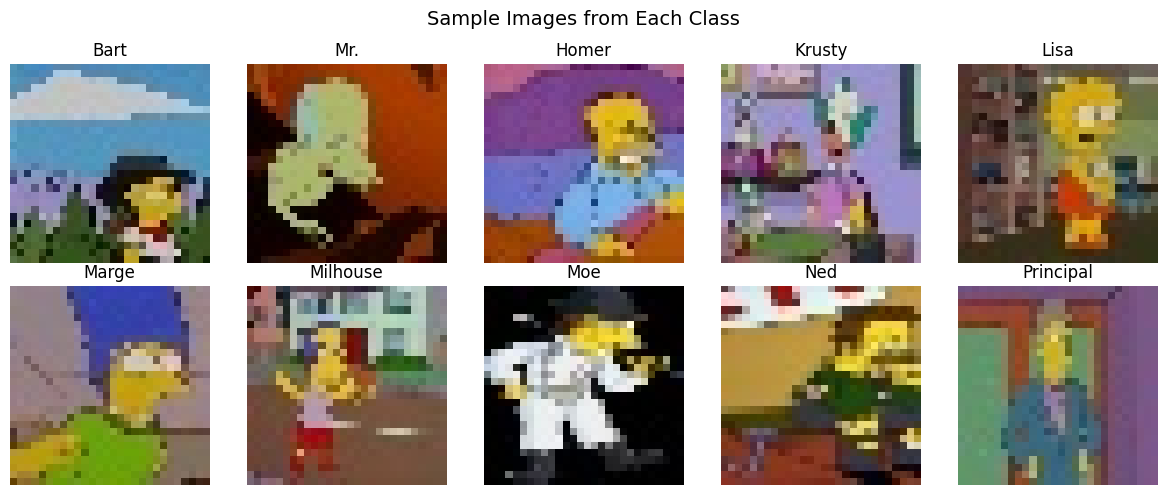

In [25]:
# Preview sample images from each class
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for label, ax in enumerate(axes.flat):
    idx = np.where(y_train_full == label)[0][0]
    ax.imshow(X_train_full[idx].reshape(28, 28, 3))
    ax.set_title(CHARACTERS[label].split()[0])  # First name only
    ax.axis('off')
plt.suptitle('Sample Images from Each Class', fontsize=14)
plt.tight_layout()

## 2. Filter to Binary Classification

For this demo, we'll focus on distinguishing Homer Simpson (label 2) vs Bart Simpson (label 0). This is a challenging task since both are yellow characters with similar skin tones!

In [26]:
# Filter to just Homer and Bart
binary_labels = [0, 2]  # Bart=0, Homer=2

# Training data
mask_train = np.isin(y_train_full, binary_labels)
X_train_binary = X_train_full[mask_train]
y_train_binary = (y_train_full[mask_train] == 2).astype(int)  # 0=Bart, 1=Homer

# Test data
mask_test = np.isin(y_test_full, binary_labels)
X_test_binary = X_test_full[mask_test]
y_test_binary = (y_test_full[mask_test] == 2).astype(int)

pd.DataFrame({
    'Split': ['Train', 'Test'],
    'Total': [len(y_train_binary), len(y_test_binary)],
    'Bart (0)': [sum(y_train_binary == 0), sum(y_test_binary == 0)],
    'Homer (1)': [sum(y_train_binary == 1), sum(y_test_binary == 1)]
})

,Split,Total,Bart (0),Homer (1)
0,Train,1600,800,800
1,Test,400,200,200


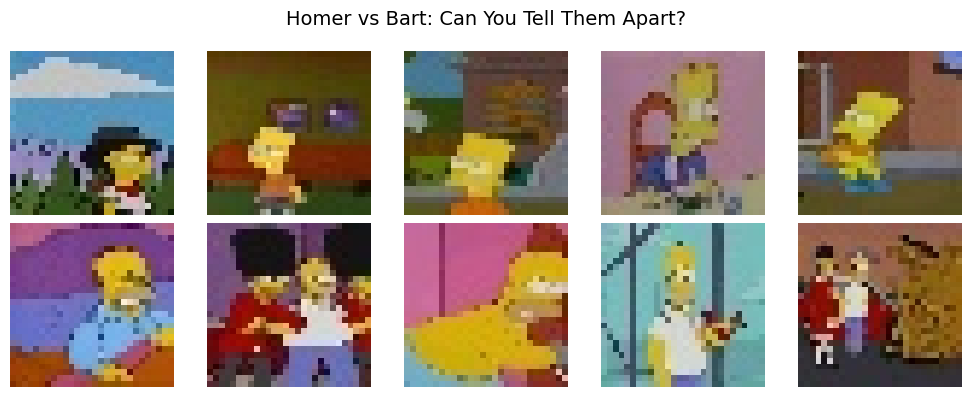

In [27]:
# Visualize samples from each class
fig, axes = plt.subplots(2, 5, figsize=(10, 4))

# Bart samples (top row)
bart_idx = np.where(y_train_binary == 0)[0][:5]
for i, ax in enumerate(axes[0]):
    ax.imshow(X_train_binary[bart_idx[i]].reshape(28, 28, 3))
    ax.axis('off')
axes[0, 0].set_ylabel('Bart', fontsize=12)

# Homer samples (bottom row)
homer_idx = np.where(y_train_binary == 1)[0][:5]
for i, ax in enumerate(axes[1]):
    ax.imshow(X_train_binary[homer_idx[i]].reshape(28, 28, 3))
    ax.axis('off')
axes[1, 0].set_ylabel('Homer', fontsize=12)

plt.suptitle('Homer vs Bart: Can You Tell Them Apart?', fontsize=14)
plt.tight_layout()

## 3. Explore the Data

With image data, pixel intensities are our features. Let's look at average images to see what the model "sees".

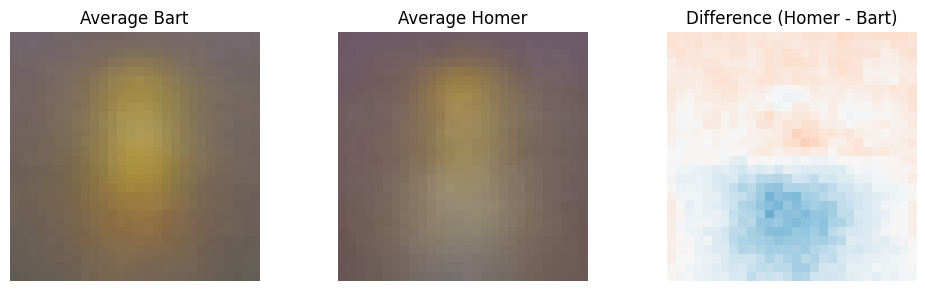

In [28]:
# Compute average image for each class (normalize to [0, 1] for display)
bart_avg = X_train_binary[y_train_binary == 0].mean(axis=0).reshape(28, 28, 3) / 255
homer_avg = X_train_binary[y_train_binary == 1].mean(axis=0).reshape(28, 28, 3) / 255

fig, axes = plt.subplots(1, 3, figsize=(10, 3))

axes[0].imshow(bart_avg)
axes[0].set_title('Average Bart')
axes[0].axis('off')

axes[1].imshow(homer_avg)
axes[1].set_title('Average Homer')
axes[1].axis('off')

# Difference image (grayscale intensity) shows discriminative regions
bart_gray = bart_avg.mean(axis=2)
homer_gray = homer_avg.mean(axis=2)
diff = homer_gray - bart_gray
axes[2].imshow(diff, cmap='RdBu', vmin=-0.2, vmax=0.2)
axes[2].set_title('Difference (Homer - Bart)')
axes[2].axis('off')

plt.tight_layout()

# Key differences: Homer's rounder head vs Bart's spiky hair

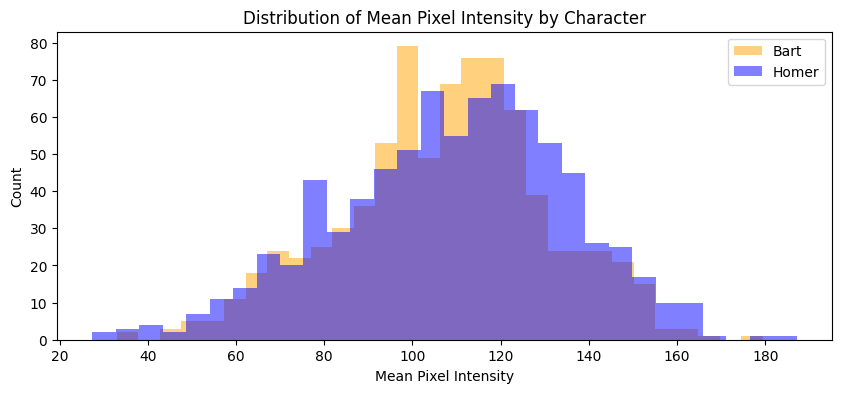

In [29]:
# Pixel intensity distributions
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(X_train_binary[y_train_binary == 0].mean(axis=1), bins=30, alpha=0.5, label='Bart', color='orange')
ax.hist(X_train_binary[y_train_binary == 1].mean(axis=1), bins=30, alpha=0.5, label='Homer', color='blue')
ax.set_xlabel('Mean Pixel Intensity')
ax.set_ylabel('Count')
ax.set_title('Distribution of Mean Pixel Intensity by Character')
ax.legend()

# Homer images tend to be slightly brighter (larger head area)

## 4. Split Data for Cross-Validation

Hold out a final test set, then use the rest for cross-validation.

In [30]:
from sklearn.model_selection import train_test_split

# Use provided train set for CV, test set for final evaluation
X_trainval = X_train_binary
y_trainval = y_train_binary
X_test = X_test_binary
y_test = y_test_binary

pd.DataFrame({
    'Split': ['Train+Validation (for CV)', 'Test (final holdout)'],
    'Samples': [len(y_trainval), len(y_test)],
    'Bart (0)': [sum(y_trainval == 0), sum(y_test == 0)],
    'Homer (1)': [sum(y_trainval == 1), sum(y_test == 1)]
})

,Split,Samples,Bart (0),Homer (1)
0,Train+Validation (for CV),1600,800,800
1,Test (final holdout),400,200,200


## 5. Compare Models with Cross-Validation

Use stratified k-fold cross-validation to compare Logistic Regression against LightGBM (a fast gradient boosting library).

In [31]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from lightgbm import LGBMClassifier

# Define models to compare
# LightGBM: fast gradient boosting, handles high-dimensional data well
models = {
    'LogisticRegression': Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    'LightGBM': LGBMClassifier(n_estimators=100, random_state=42, verbosity=-1)
}

# Set up stratified k-fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Run CV for each model
cv_results = []
for name, model in models.items():
    scores = cross_val_score(model, X_trainval, y_trainval, cv=cv, scoring='roc_auc')
    for fold, score in enumerate(scores, 1):
        cv_results.append({'model': name, 'fold': fold, 'auc': score})

cv_df = pd.DataFrame(cv_results)
cv_df.pivot(index='fold', columns='model', values='auc')

/Users/christopher/Documents/datasci_223/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/christopher/Documents/datasci_223/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/christopher/Documents/datasci_223/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/christopher/Documents/datasci_223/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/christopher/Documents/datasci_223/.venv/lib/python3.12/site-packages/sklearn/utils/valida

model,LightGBM,LogisticRegression
fold,,
1,0.932891,0.791758
2,0.930781,0.777109
3,0.905234,0.753125
4,0.894414,0.789648
5,0.889531,0.746719


In [32]:
# Summary statistics
cv_df.groupby('model')['auc'].agg(['mean', 'std']).round(3)

,mean,std
model,,
LightGBM,0.911,0.020
LogisticRegression,0.772,0.021


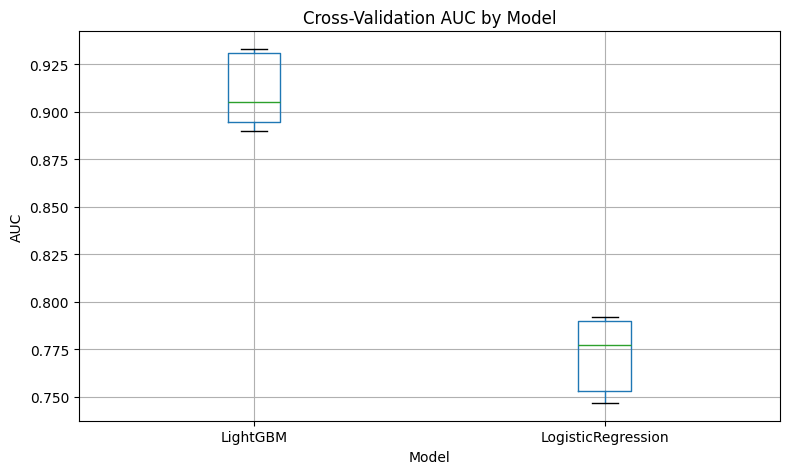

In [33]:
# Visualize CV results
fig, ax = plt.subplots(figsize=(8, 5))
cv_df.boxplot(column='auc', by='model', ax=ax)
ax.set_title('Cross-Validation AUC by Model')
ax.set_xlabel('Model')
ax.set_ylabel('AUC')
plt.suptitle('')
plt.tight_layout()

# LightGBM typically performs well on image data flattened to tabular format

## 6. Train All Models

Train all models on the full training set so we can compare their ROC curves.

In [34]:
# Train all models on full training data
trained_models = {}
for name, model in models.items():
    model.fit(X_trainval, y_trainval)
    trained_models[name] = model

# Identify best model by CV score
best_model_name = cv_df.groupby('model')['auc'].mean().idxmax()
best_pipeline = trained_models[best_model_name]

f"Best model: {best_model_name}"

'Best model: LightGBM'

## 7. Final Evaluation on Test Set

Evaluate on the held-out test set—this is the first and only time we use this data.

/Users/christopher/Documents/datasci_223/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/christopher/Documents/datasci_223/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Text(0.5, 1.0, 'Confusion Matrix (Test Set)')

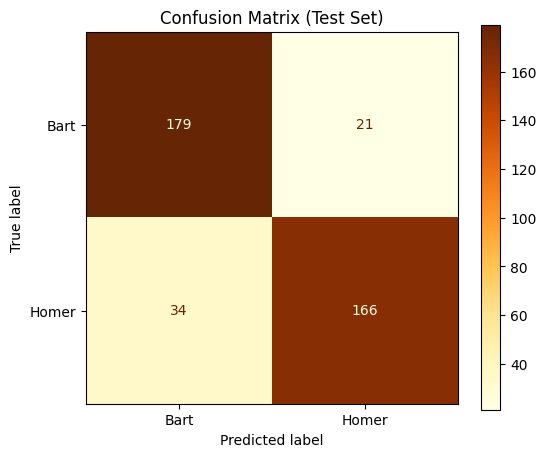

In [35]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
    ConfusionMatrixDisplay
)

# Make predictions on held-out test set
y_pred = best_pipeline.predict(X_test)
y_prob = best_pipeline.predict_proba(X_test)[:, 1]

# Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Bart', 'Homer'])
disp.plot(ax=ax, cmap='YlOrBr')
ax.set_title('Confusion Matrix (Test Set)')

In [36]:
# Classification Report
classification_report(y_test, y_pred, target_names=['Bart', 'Homer'], output_dict=True)

{'Bart': {'precision': 0.8403755868544601,
  'recall': 0.895,
  'f1-score': 0.8668280871670703,
  'support': 200.0},
 'Homer': {'precision': 0.8877005347593583,
  'recall': 0.83,
  'f1-score': 0.8578811369509044,
  'support': 200.0},
 'accuracy': 0.8625,
 'macro avg': {'precision': 0.8640380608069091,
  'recall': 0.8625,
  'f1-score': 0.8623546120589873,
  'support': 400.0},
 'weighted avg': {'precision': 0.8640380608069091,
  'recall': 0.8625,
  'f1-score': 0.8623546120589873,
  'support': 400.0}}

/Users/christopher/Documents/datasci_223/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


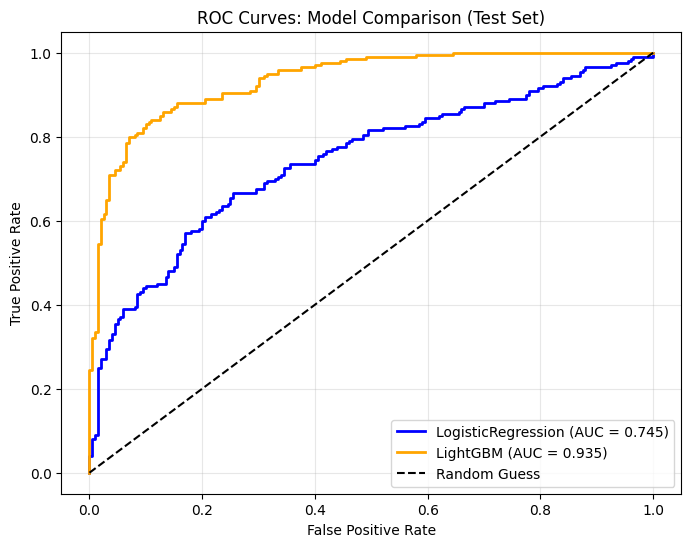

In [37]:
# ROC Curves for both models
plt.figure(figsize=(8, 6))
colors = {'LogisticRegression': 'blue', 'LightGBM': 'orange'}

test_results = []
for name, model in trained_models.items():
    y_prob_model = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob_model)
    auc = roc_auc_score(y_test, y_prob_model)
    plt.plot(fpr, tpr, color=colors[name], linewidth=2, label=f'{name} (AUC = {auc:.3f})')
    test_results.append({'model': name, 'test_auc': auc})

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves: Model Comparison (Test Set)')
plt.legend()
plt.grid(True, alpha=0.3)

In [38]:
# Compare CV AUC vs Test AUC for both models
cv_summary = cv_df.groupby('model')['auc'].mean().reset_index()
cv_summary.columns = ['model', 'cv_auc']
test_df = pd.DataFrame(test_results)
comparison = cv_summary.merge(test_df, on='model')
comparison['diff'] = comparison['test_auc'] - comparison['cv_auc']
comparison.round(3)

,model,cv_auc,test_auc,diff
0,LightGBM,0.911,0.935,0.025
1,LogisticRegression,0.772,0.745,-0.027


## 8. Interpret the Model

Examine which pixels are most important for distinguishing Homer from Bart.

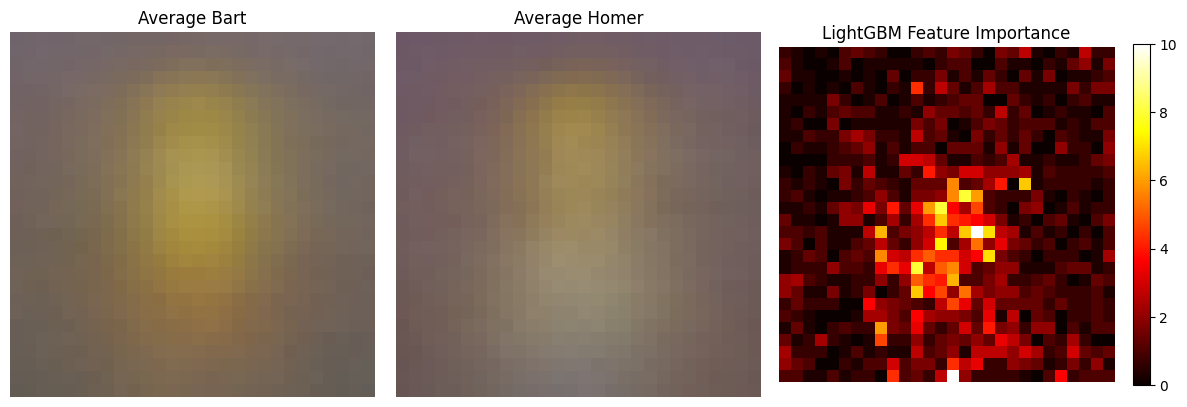

In [39]:
# Get feature importances from the trained model
# LightGBM uses feature_importances_, LogisticRegression uses coef_
# With RGB, we have 2352 features (28x28x3) - average across channels for visualization
if hasattr(best_pipeline, 'feature_importances_'):
    # LightGBM
    importances = best_pipeline.feature_importances_.reshape(28, 28, 3).mean(axis=2)
    cmap, title = 'hot', f'{best_model_name} Feature Importance'
    vmin, vmax = 0, importances.max()
else:
    # Logistic Regression (inside pipeline)
    importances = best_pipeline.named_steps['classifier'].coef_[0].reshape(28, 28, 3).mean(axis=2)
    cmap, title = 'Coefficients (Blue=Bart, Red=Homer)'
    vmin, vmax = -0.1, 0.1

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(bart_avg)
axes[0].set_title('Average Bart')
axes[0].axis('off')

axes[1].imshow(homer_avg)
axes[1].set_title('Average Homer')
axes[1].axis('off')

im = axes[2].imshow(importances, cmap=cmap, vmin=vmin, vmax=vmax)
axes[2].set_title(title)
axes[2].axis('off')
plt.colorbar(im, ax=axes[2], fraction=0.046)

plt.tight_layout()

# Key discriminators: Bart's spiky hair vs Homer's round head

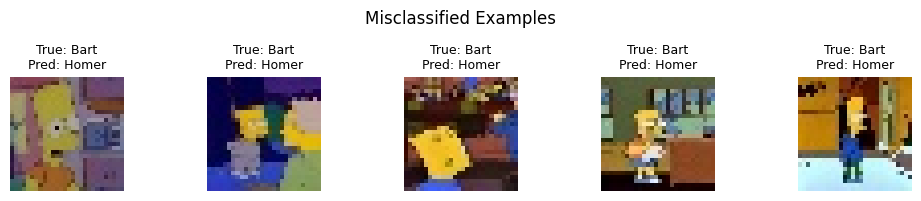

In [40]:
# Show some misclassified examples
misclassified = np.where(y_pred != y_test)[0]
if len(misclassified) > 0:
    fig, axes = plt.subplots(1, min(5, len(misclassified)), figsize=(10, 2))
    if len(misclassified) == 1:
        axes = [axes]
    for i, idx in enumerate(misclassified[:5]):
        axes[i].imshow(X_test[idx].reshape(28, 28, 3))
        true_label = 'Homer' if y_test[idx] == 1 else 'Bart'
        pred_label = 'Homer' if y_pred[idx] == 1 else 'Bart'
        axes[i].set_title(f'True: {true_label}\nPred: {pred_label}', fontsize=9)
        axes[i].axis('off')
    plt.suptitle('Misclassified Examples', fontsize=12)
    plt.tight_layout()

## Takeaways

- **Image data as flat vectors** - each 28x28x3 RGB image becomes 2352 features (one per pixel per channel)
- **Model comparison with CV** - compare multiple models (e.g., Logistic Regression vs LightGBM) using cross-validation before selecting the best
- **LightGBM for tabular data** - gradient boosting methods often outperform linear models on flattened image data
- **Pipeline for proper preprocessing** - putting scaler inside the pipeline prevents data leakage across CV folds
- **Visual interpretation** - with image data, we can visualize feature importance to see what the model "looks for"
- **Distinguishing features** - Bart's spiky hair vs Homer's round bald head are the key discriminators